# Find alpha DSE1-4

May 4, 2025 - An attempt to reproduce the find alpha parameter using the DSE genes. The differences in the replicate fits and the shorter delta values make this procedure difficult to reliably reproduce consistently across both replicates. Replicate 1 produces very long alphas > 28, replicate 2 produces very short ones < 8. Whereas we would expect values between 12-20 proportionally to the length of the cell cycle as per Xin Guo's work.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Creating directory: output/draft3_run//alpha_search...Directory exists. Skipping.
Number of alphas: 5
Testing alpha values: [16, 20, 24, 32, 36]
Running for genes: ['DSE1', 'DSE2', 'DSE3', 'DSE4']
Searching replicate 1 alphas: DSE1...
16,20,24,32,36,
00:00:51.743
Searching replicate 1 alphas: DSE2...
16,20,24,32,36,
00:01:41.965
Searching replicate 1 alphas: DSE3...
16,20,24,32,36,
00:02:32.163
Searching replicate 1 alphas: DSE4...
16,20,24,32,36,
00:03:22.148
Searching replicate 2 alphas: DSE1...
16,20,24,32,36,
00:04:11.706
Searching replicate 2 alphas: DSE2...
16,20,24,32,36,
00:05:02.734
Searching replicate 2 alphas: DSE3...
16,20,24,32,36,
00:05:52.534
Searching replicate 2 alphas: DSE4...
16,20,24,32,36,
00:06:41.204
Results saved to output/draft3_run//alpha_search


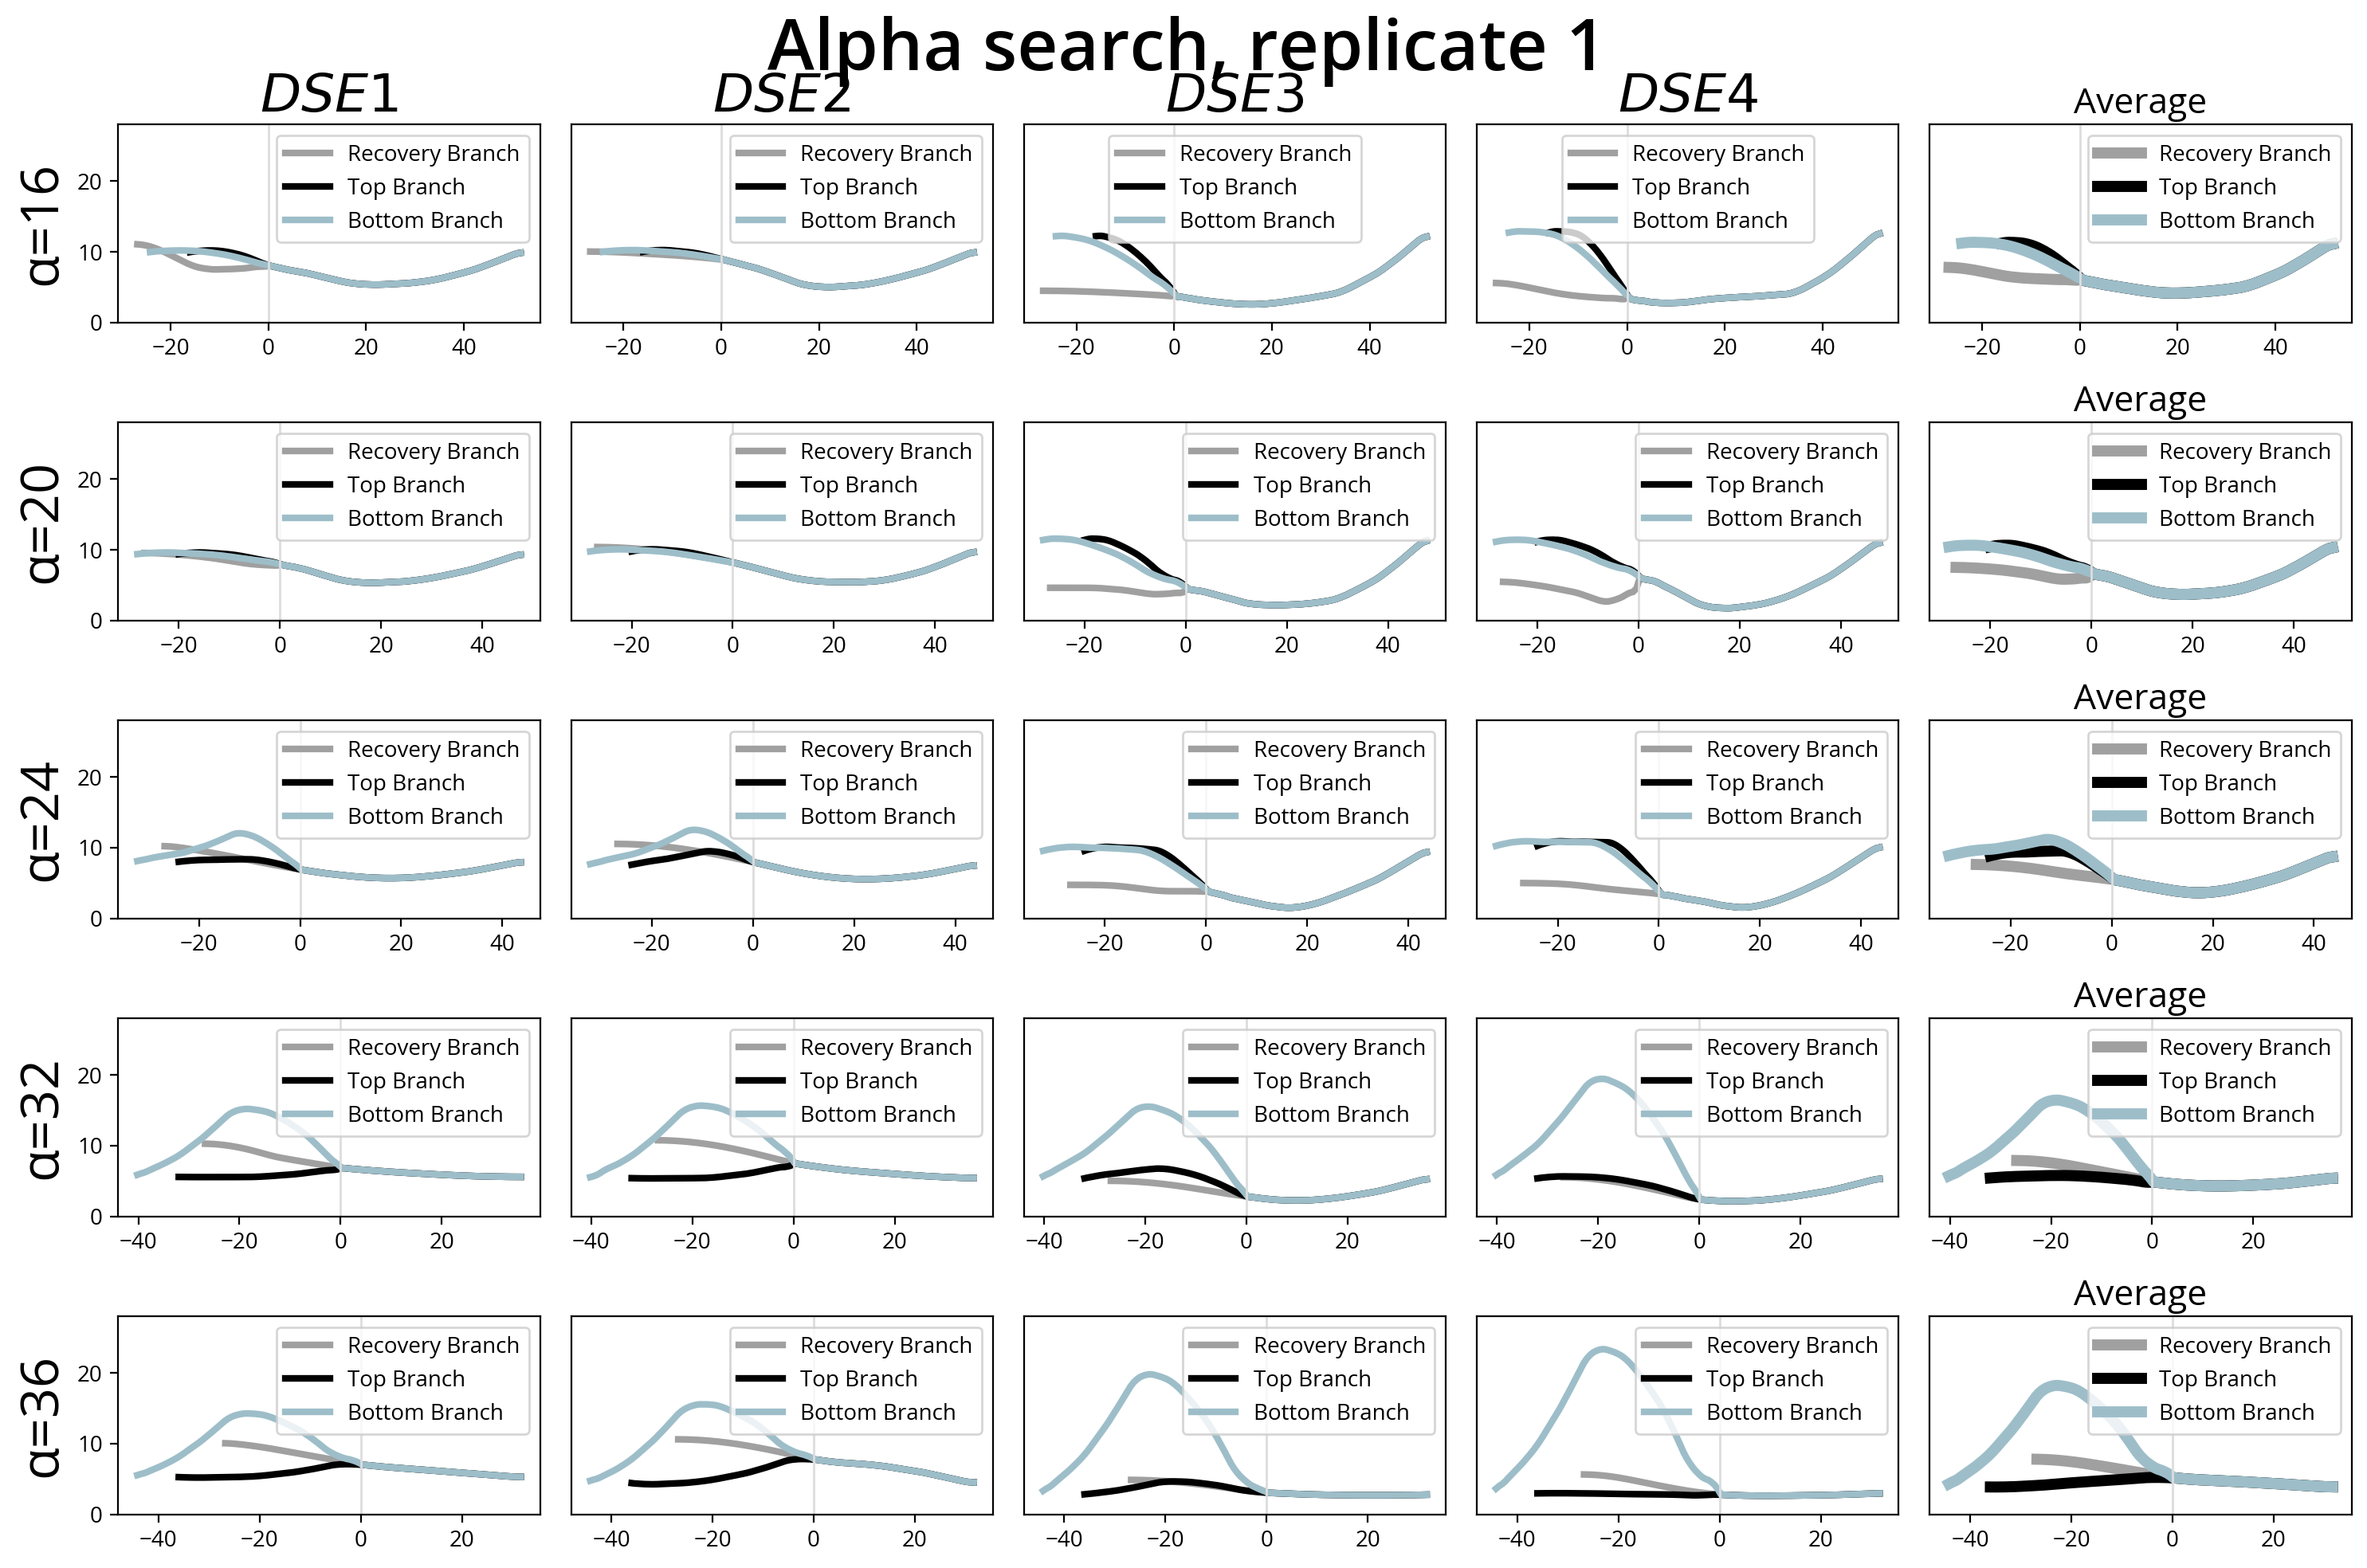

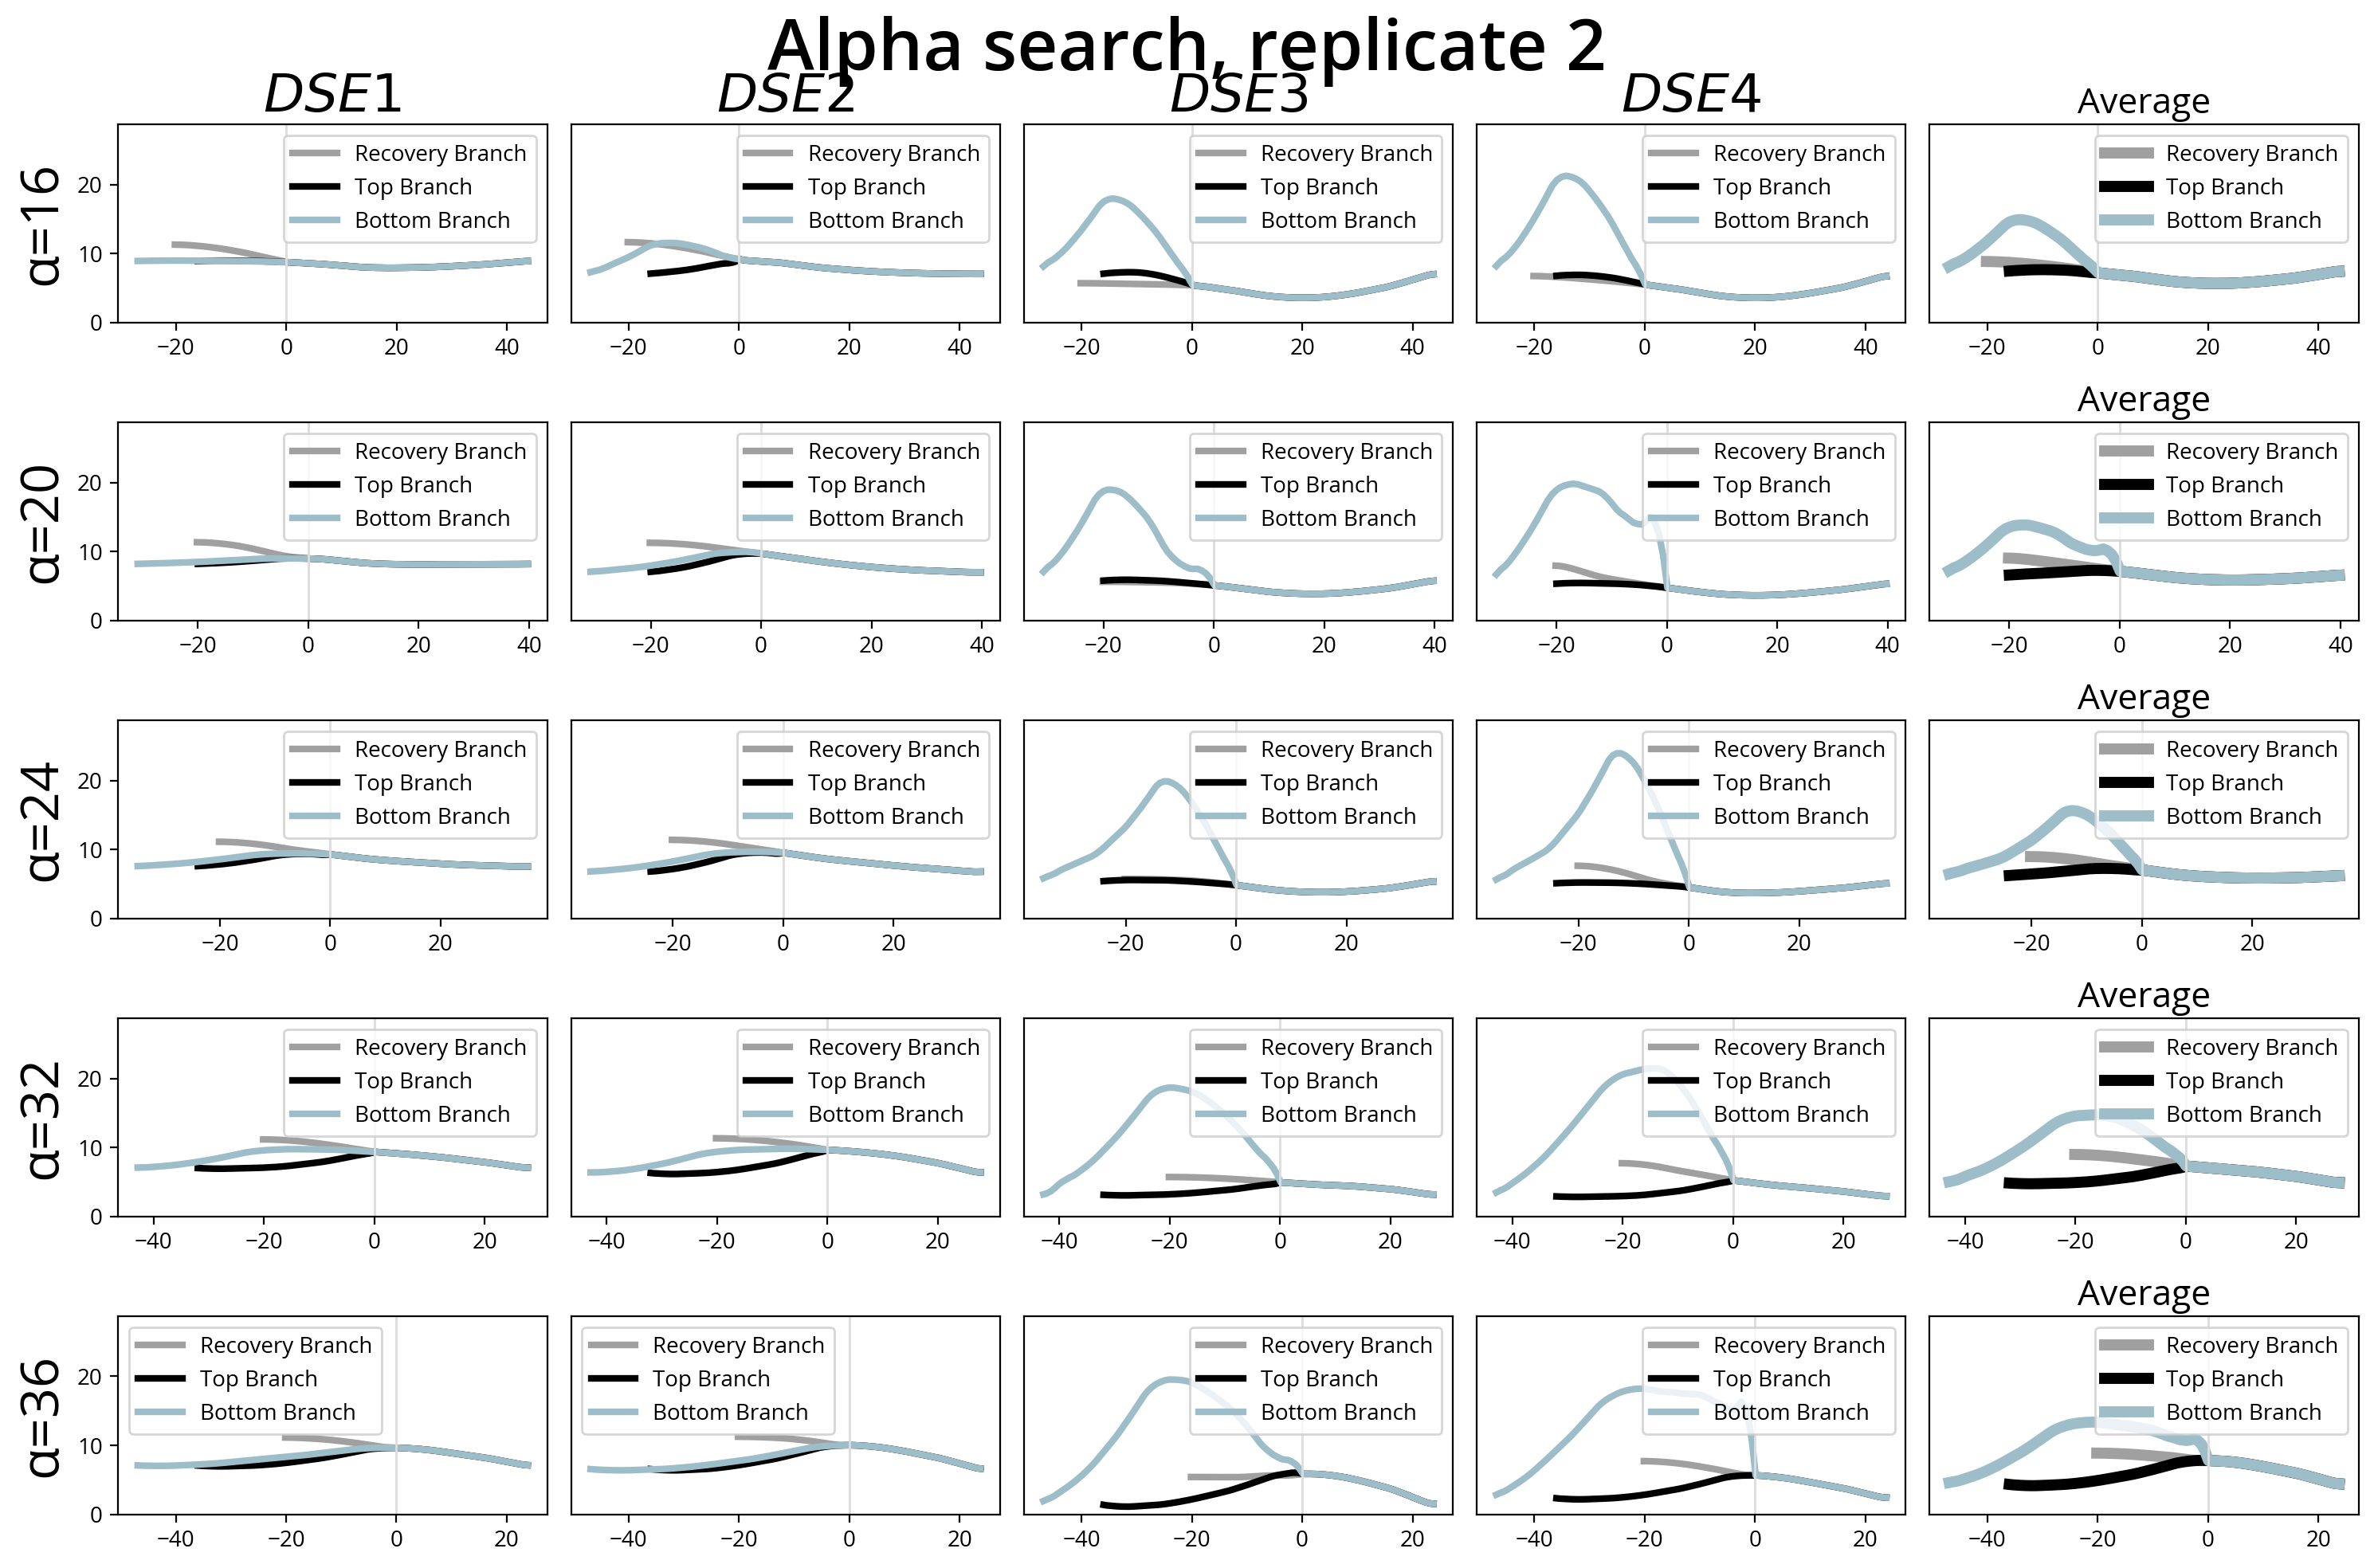

In [2274]:
from src.alpha_search import FindAlphaSweepDS

finder = FindAlphaSweepDS(output_directory='output/draft3_run/', 
    gene_names=['DSE1', 'DSE2', 'DSE3', 'DSE4'])
finder.run_alpha_sweep(alphas=[16, 20, 24, 32, 36])
finder.plot_and_save_results(save=False)


In [2542]:
# Load the existing alpha search run data
alpha_results_df = pd.read_csv('output/draft3_run/alpha_search/alphas_repl1.csv')\
    .set_index(['replicate', 'alpha', 'gene'])
alpha_results_df.columns = alpha_results_df.columns.astype(int)

In [2346]:
from src.config import load_default_chrom_configs
config1, config2 = load_default_chrom_configs()

# Compute the DG1 / MG1 ratios for each gene alpha combination
results = alpha_results_df
dg1_mg1_ratios = results[[]].copy()
dg1_mg1_ratios['dm_ratio'] = None  # Pre-create column
alphas = dg1_mg1_ratios.index.get_level_values(1).unique()

for replicate in [1, 2]:
    for alpha in alphas:
        config = config1 if replicate == 1 else config2
        config.modify_alpha(alpha)

        gene_results = results.loc[replicate].loc[alpha]
        gene_dg1_cg1_ratios = gene_results[config.get_Hpositions_for_phase('DG1')].mean(1) / \
            gene_results[config.get_Hpositions_for_phase('CG1')].mean(1)

        # Use at instead of loc for single assignments
        for gene_idx in gene_dg1_cg1_ratios.index:
            dg1_mg1_ratios.at[(replicate, alpha, gene_idx), 'dm_ratio'] = \
                gene_dg1_cg1_ratios[gene_idx]


Text(0.5, 1.1, 'Range of $\\alpha$ values with high ratio of DG1/MG1 expression')

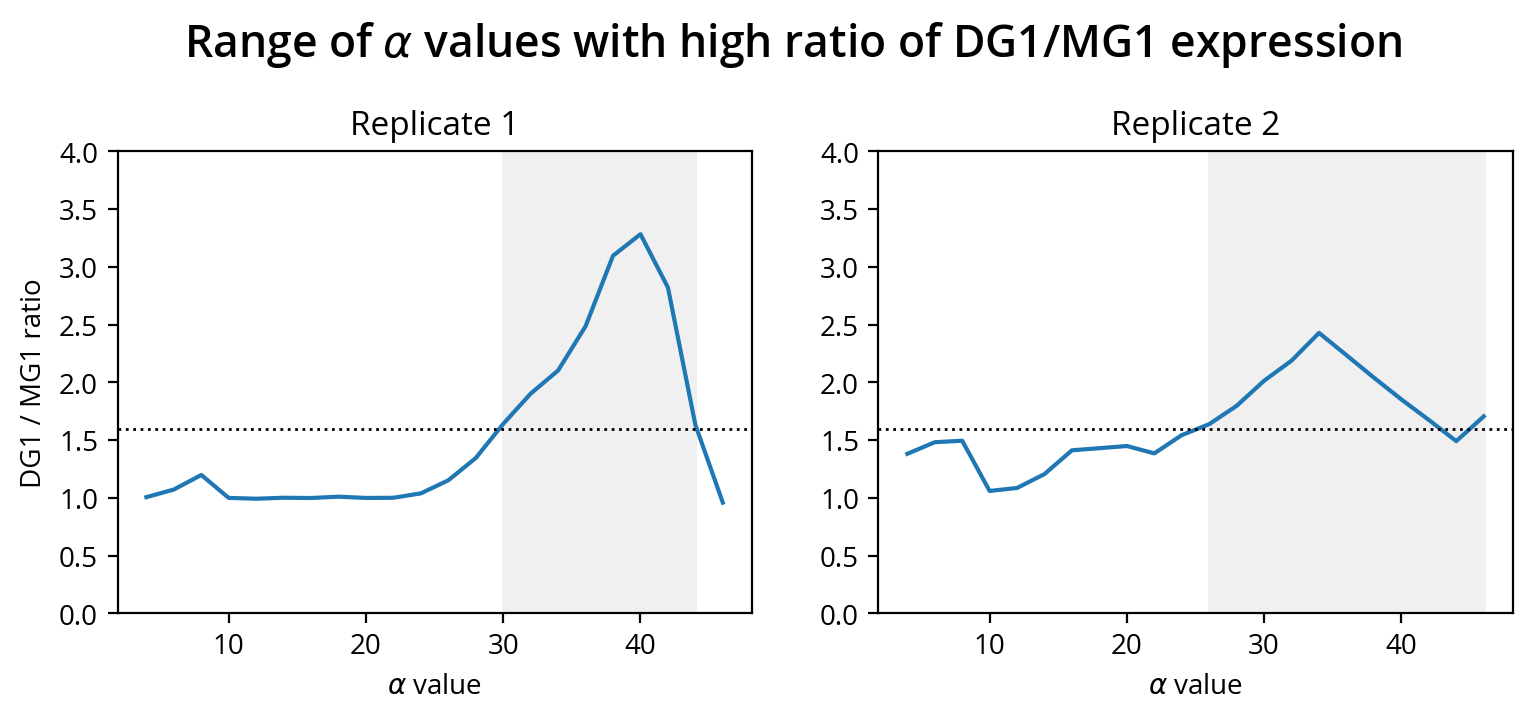

In [2543]:
# Compute the thresholded mean ratios based on fixed threshold (1.6 is a lenient threshold) 
threshold = 1.6

mean_ratios = dg1_mg1_ratios.groupby(['replicate', 'alpha']).mean()
thresholded_mean_ratios = mean_ratios[mean_ratios.dm_ratio > 
    threshold]
ratios_rep1_range = thresholded_mean_ratios.loc[1].index.min(), \
    thresholded_mean_ratios.loc[1].index.max()
ratios_rep2_range = thresholded_mean_ratios.loc[2].index.min(), \
    thresholded_mean_ratios.loc[2].index.max()

# Plot the DG1/MG1 ratios
plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1)
plt.plot(mean_ratios.loc[1].index, mean_ratios.loc[1].dm_ratio)
plt.title("Replicate 1")
plt.xlabel("$\\alpha$ value")
plt.ylabel("DG1 / MG1 ratio")
plt.ylim(0, 4)

plt.axhline(threshold, c='black', ls='dotted', lw=1)
plt.axvspan(ratios_rep1_range[0], ratios_rep1_range[1], 0, 4, color='#f0f0f0')

plt.subplot(1, 2, 2)
plt.plot(mean_ratios.loc[2].index, mean_ratios.loc[2].dm_ratio)
plt.title("Replicate 2")
plt.xlabel("$\\alpha$ value")
plt.ylim(0, 4)
plt.axhline(threshold, c='black', ls='dotted', lw=1)
plt.axvspan(ratios_rep2_range[0], ratios_rep2_range[1], 0, 4, color='#f0f0f0')

plt.suptitle("Range of $\\alpha$ values with high ratio of DG1/MG1 expression",
            fontweight='demi', fontsize=16, y=1.1)

In [2389]:
from scipy.stats import pearsonr
import pandas as pd
from src.timer import Timer
from src.helpers import interpolate_increase_length

timer = Timer()
# Create DataFrame for storing correlations
# Structure: (alpha1, alpha2, gene) -> correlation values
correlation_results = []

# Get all genes from your existing data
genes = dg1_mg1_ratios.index.get_level_values(2).unique()

for alpha1 in alphas:
    for alpha2 in alphas:

        config1.modify_alpha(alpha1)
        config2.modify_alpha(alpha2)

        gene_results1 = results.loc[1].loc[alpha1]
        gene_results2 = results.loc[2].loc[alpha2]
        
        # Retrieve the branch data for each replicate for a gene
        # Interpolate in the case of uneven number of indices
        def retrieve_branch_data(gene_results1, gene_results2, gene_idx, branch):
            # Get the data for this specific gene from both replicates
            gene1_data = gene_results1.loc[gene_idx][config1.get_Hpositions_for_branch('b')]
            gene2_data = gene_results2.loc[gene_idx][config2.get_Hpositions_for_branch('b')]
            
            if len(gene1_data) > len(gene2_data):
                gene2_data = interpolate_increase_length(gene2_data, len(gene1_data))
            elif len(gene1_data) < len(gene2_data):
                gene1_data = interpolate_increase_length(gene1_data, len(gene2_data))
            return gene1_data, gene2_data
                
        for gene_idx in genes:

            # Get the data for this specific gene from both replicates
            b1, b2 = retrieve_branch_data(gene_results1, gene_results2, gene_idx,
                                             'b')
            t1, t2 = retrieve_branch_data(gene_results1, gene_results2, gene_idx,
                                             't')
            r1, r2 = retrieve_branch_data(gene_results1, gene_results2, gene_idx,
                                             't')

            # Concatenate and correlate all branches
            gene1_data = np.concatenate([r1, b1, t1])
            gene2_data = np.concatenate([r2, b2, t2])

            correlation, p_value = pearsonr(gene1_data, gene2_data)

            correlation_results.append({
                'alpha1': alpha1,
                'alpha2': alpha2,
                'gene': gene_idx,
                'correlation': correlation,
                'p_value': p_value,
                'n_points': min(len(gene1_data), len(gene2_data))
            })
    timer.print_time()

# Convert to DataFrame
pearson_correlations = pd.DataFrame(correlation_results)
pearson_correlations = pearson_correlations.set_index(['alpha1', 'alpha2', 'gene'])

(4, 4), (4, 6), (4, 8), (4, 10), (4, 12), (4, 14), (4, 16), (4, 18), (4, 20), (4, 22), (4, 24), (4, 26), (4, 28), (4, 30), (4, 32), (4, 34), (4, 36), (4, 38), (4, 40), (4, 42), (4, 44), (4, 46), 00:00:10.219
(6, 4), (6, 6), (6, 8), (6, 10), (6, 12), (6, 14), (6, 16), (6, 18), (6, 20), (6, 22), (6, 24), (6, 26), (6, 28), (6, 30), (6, 32), (6, 34), (6, 36), (6, 38), (6, 40), (6, 42), (6, 44), (6, 46), 00:00:20.819
(8, 4), (8, 6), (8, 8), (8, 10), (8, 12), (8, 14), (8, 16), (8, 18), (8, 20), (8, 22), (8, 24), (8, 26), (8, 28), (8, 30), (8, 32), (8, 34), (8, 36), (8, 38), (8, 40), (8, 42), (8, 44), (8, 46), 00:00:30.513
(10, 4), (10, 6), (10, 8), (10, 10), (10, 12), (10, 14), (10, 16), (10, 18), (10, 20), (10, 22), (10, 24), (10, 26), (10, 28), (10, 30), (10, 32), (10, 34), (10, 36), (10, 38), (10, 40), (10, 42), (10, 44), (10, 46), 00:00:40.687
(12, 4), (12, 6), (12, 8), (12, 10), (12, 12), (12, 14), (12, 16), (12, 18), (12, 20), (12, 22), (12, 24), (12, 26), (12, 28), (12, 30), (12, 32),

In [2448]:
correlation_means = pearson_correlations.groupby(['alpha1', 'alpha2']).mean()[['correlation']]
a1_a2_cor_pivot = correlation_means.reset_index().pivot(index='alpha1', 
    columns='alpha2', values='correlation')

(26, 30, 44, 46)

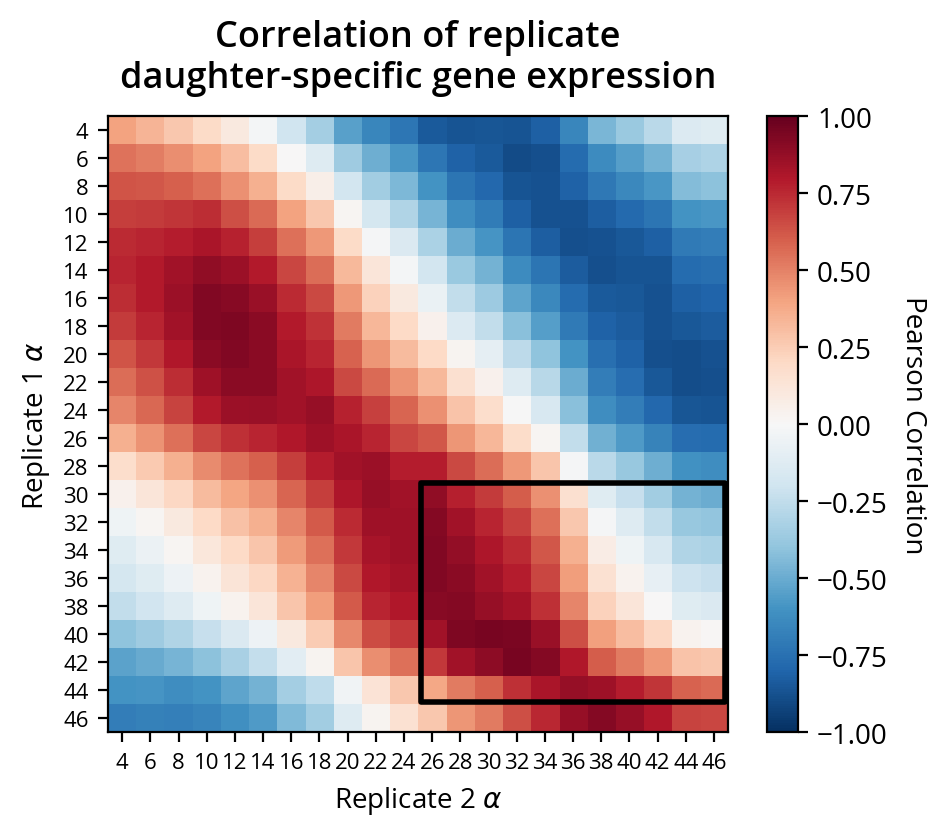

In [2541]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(5, 4))

# Display the heatmap
im = ax.imshow(a1_a2_cor_pivot, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1,
               origin='lower',
              extent=[a1_a2_cor_pivot.index[0]-1, a1_a2_cor_pivot.index[-1]+1, 
                      a1_a2_cor_pivot.columns[0]-1, a1_a2_cor_pivot.columns[-1]+1])

# Set the ticks and labels
ax.set_xticks(a1_a2_cor_pivot.columns, a1_a2_cor_pivot.columns, fontsize=8)
ax.set_yticks(a1_a2_cor_pivot.index, a1_a2_cor_pivot.columns, fontsize=8)

# Add colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel('Pearson Correlation', 
    rotation=-90, va="bottom")

ax.set_title("Correlation of replicate\ndaughter-specific gene expression", 
    fontweight='demi', fontsize=13, y=1.02)
ax.set_xlabel('Replicate 2 $\\alpha$')
ax.set_ylabel('Replicate 1 $\\alpha$')
ax.set_ylim(ax.get_ylim()[1], ax.get_ylim()[0])

from src.plot_helpers import plot_rect2

ax = plt.gca()
plot_rect2(ax, ratios_rep2_range[0]-0.8, ratios_rep1_range[0]-0.8, 
           ratios_rep2_range[1]+0.8, 
            ratios_rep1_range[1]+0.8, edgecolor='black', lw=2, ls='solid',
           facecolor='none')

ratios_rep2_range[0], ratios_rep1_range[0], ratios_rep1_range[1],  ratios_rep2_range[1]


In [2450]:
# Look at the combined expression profiles for a set of the highly-correlated pairs
correlation_means = correlation_means.sort_values('correlation', ascending=False)

In [2451]:
# Mean ratios above lenient threshold,
thresholded_ratios = mean_ratios[mean_ratios > 1.6].dropna()
thresholded_ratios1 = thresholded_ratios.loc[1]
thresholded_ratios2 = thresholded_ratios.loc[2]

In [2456]:
final_set_indices = correlation_means.index[correlation_means.reset_index()['alpha1'].isin(thresholded_ratios1.index) &
    correlation_means.reset_index()['alpha2'].isin(thresholded_ratios2.index)]
correlation_means.loc[final_set_indices].head(20)

correlation
alpha1 alpha2             
42     32         0.947019
40     30         0.946045
       32         0.941301
       28         0.933257
34     26         0.928326
36     26         0.924999
42     34         0.920352
38     28         0.919036
32     26         0.916677
38     26         0.910042
36     28         0.900259
42     30         0.892047
30     26         0.885175
34     28         0.876360
44     36         0.870710
38     30         0.870083
40     34         0.860905
44     38         0.845773
42     28         0.838158
32     28         0.837219